In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import bte
import matplotlib as mpl
import seaborn as sns


Notebook to visualise Molnupiravir clusters with singletons from UShER phylogenies. Molnupiravir-like nodes are defined as nodes with LLRs > 3 and sum_contexts > 2.

In [2]:
df = pd.read_csv("/Users/reem/merged_bte_final.tsv", sep="\t")
df.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],['G15910T'],1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,China,2020,1
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],['G4162T'],1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,NaN,2020,1
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,['T13090C'],1,2,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,2
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"['C1191T', 'C11674T']",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,0.0,"Counter({'C[C>T]A': 1, 'A[C>T]T': 1})",-0.351044,Counter(),0.000000,0.521315,-0.351044,England,2020,1
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],['T15821C'],1,3,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,1


In [ ]:
tree = bte.MATree(pb_file="/Users/reem/2026_updated_tree.pb")

In [13]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go


# Plot figure 1A and B
# Figure1A: Number of sequenced genomes in Australia and France over the years
# Figure 1B : Number of molnupiravir nodes in both countries across the years using thresholds LLR>3 and context_llr>2
aus_df = df[df["country"] == "Australia"]
fra_df = df[df["country"] == "France"]
country_df = pd.concat([aus_df, fra_df], ignore_index=True)
years = [2020, 2021, 2022, 2023, 2024, 2025]

# Panel A - total genomes per year per country
aus_counts = aus_df["date"].value_counts().sort_index().reindex(years, fill_value=0)    
fra_counts = fra_df["date"].value_counts().sort_index().reindex(years, fill_value=0)

# Panel B - MOV nodes per year per country
rows = []
for year in years:
    df_yr = country_df[country_df["date"]==year]
    Mov_pred = (df_yr["LLR"] > 3) & (df_yr["sum_contexts"] > 2)
    rows.append({
        "year": year,
        "Australia_prop": Mov_pred[df_yr["country"]=="Australia"].sum()/len(df_yr[df_yr["country"]=="Australia"])*100,
        "France_prop": Mov_pred[df_yr["country"]=="France"].sum()/len(df_yr[df_yr["country"]=="France"])*100,
    })
prop_df = pd.DataFrame(rows)  

# Create subplots
fig = make_subplots(rows=1, cols=2)

# Add traces for panel A
fig.add_trace(go.Bar(x=years, y=aus_counts.values, name="Australia", marker_color='#1f77b4', legendgroup="aus"), row=1, col=1)
fig.add_trace(go.Bar(x=years, y=fra_counts.values, name="France", marker_color= '#ff7f0e', legendgroup="fra"), row=1, col=1)

# Add traces for panel B
fig.add_trace(go.Bar(x=prop_df["year"], y=prop_df["Australia_prop"], name="Australia", marker_color='#1f77b4', legendgroup="aus",showlegend=False), row=1, col=2)
fig.add_trace(go.Bar(x=prop_df["year"], y=prop_df["France_prop"], name="France", marker_color= '#ff7f0e', legendgroup="fra", showlegend=False), row=1, col=2)

# Update layout
fig.update_layout(barmode='group', width = 1000, height = 450, template = "simple_white", margin=dict(l=40, r=40, t=60, b=40))

fig.update_xaxes(title_text="Year", tickmode='linear', dtick=1)
fig.update_yaxes(title_text="Number of Genomes", row=1, col=1)
fig.update_yaxes(title_text="Percentage of molnupiravir nodes", row=1, col=2)
fig.show()

fig.write_image("/Users/reem/Mov/nextclade_results/molnupiravir_misc/Figures/Figure1_Aus_France.pdf")  


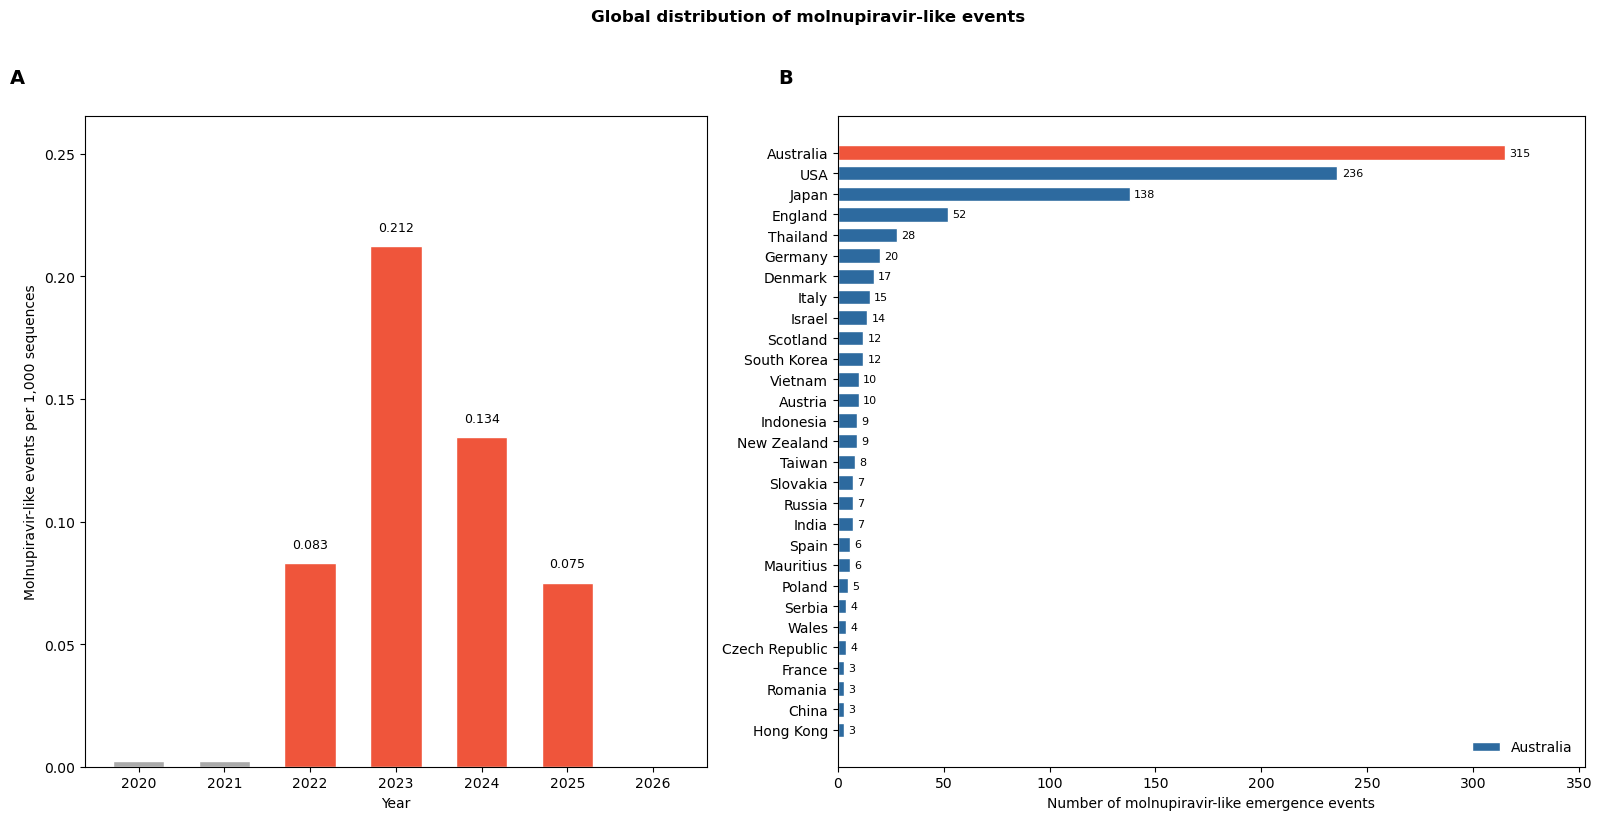

In [6]:
# Figure 3A - Molnupiravir events per 1000 sequences across the years
# Figure 3B - Geographical distribution of molnupiravir nodes

df["is_mov"] = (df["LLR"] > 3) & (df["sum_contexts"] > 2)
df = df[~df["date"].isin([1905,1973,1993,0,2019])]  # Exclude irrelevant years


gisaid = pd.read_csv("/Users/reem/total_seqs_per_year.tsv", sep="\t").rename(columns={"count": "total_seqs"})

yearly = df.groupby("date")["is_mov"].sum().reset_index(name="mov_count").merge(gisaid, left_on="date", right_on="year").assign(mov_per_1000=lambda x: x["mov_count"] / x["total_seqs"] * 1000)
countries = pd.read_csv("/Users/reem/merged_bte_mov_strict.tsv", sep="\t")

# Excluding countries with <-= 2 clusters for better visualization
country_counts = countries["country"].str.strip()\
    .str.replace("SouthKorea", "South Korea")\
    .str.replace("NewZealand", "New Zealand")\
    .str.replace("CzechRepublic", "Czech Republic")\
    .value_counts().reset_index(name="n_clusters")\
    .query("n_clusters > 2")\
    .sort_values("n_clusters")

BLUE = "#2D6A9F"
RED  = "#EF553B"
GRAY = "#AAAAAA"

# ── Figure ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8),gridspec_kw={"width_ratios": [1, 1.2]})

# Panel A
years = yearly["date"].astype(str)
colors_a = [GRAY if y in ["2020", "2021"] else RED for y in years]
bars = ax1.bar(years, yearly["mov_per_1000"], color=colors_a, edgecolor="white", width=0.6)

for bar, val in zip(bars, yearly["mov_per_1000"]):
    if val > 0.01:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax1.set(xlabel="Year", ylabel="Molnupiravir-like events per 1,000 sequences",
        ylim=(0, yearly["mov_per_1000"].max() * 1.25))
ax1.text(-0.12, 1.05, "A", transform=ax1.transAxes, fontsize=14, fontweight="bold")

# Panel B
colors_b = [RED if c == "Australia" else BLUE for c in country_counts["country"]]
ax2.barh(country_counts["country"], country_counts["n_clusters"],
         color=colors_b, edgecolor="white", height=0.7, label="Australia")

for i, val in enumerate(country_counts["n_clusters"]):
    ax2.text(val + 2, i, str(int(val)), va="center", fontsize=8)

ax2.set(xlabel="Number of molnupiravir-like emergence events",
        xlim=(0, country_counts["n_clusters"].max() * 1.12))
ax2.legend(frameon=False, loc="lower right")
ax2.text(-0.08, 1.05, "B", transform=ax2.transAxes, fontsize=14, fontweight="bold")

plt.suptitle("Global distribution of molnupiravir-like events", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/Users/reem/molnupiravir_paper/Figures/figure3_global_dist.pdf", format = "pdf", bbox_inches="tight")
plt.show()


/var/folders/bt/jpy5j9ms7pb6p6hhqzvpjffw0000gn/T/ipykernel_93438/3975166011.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



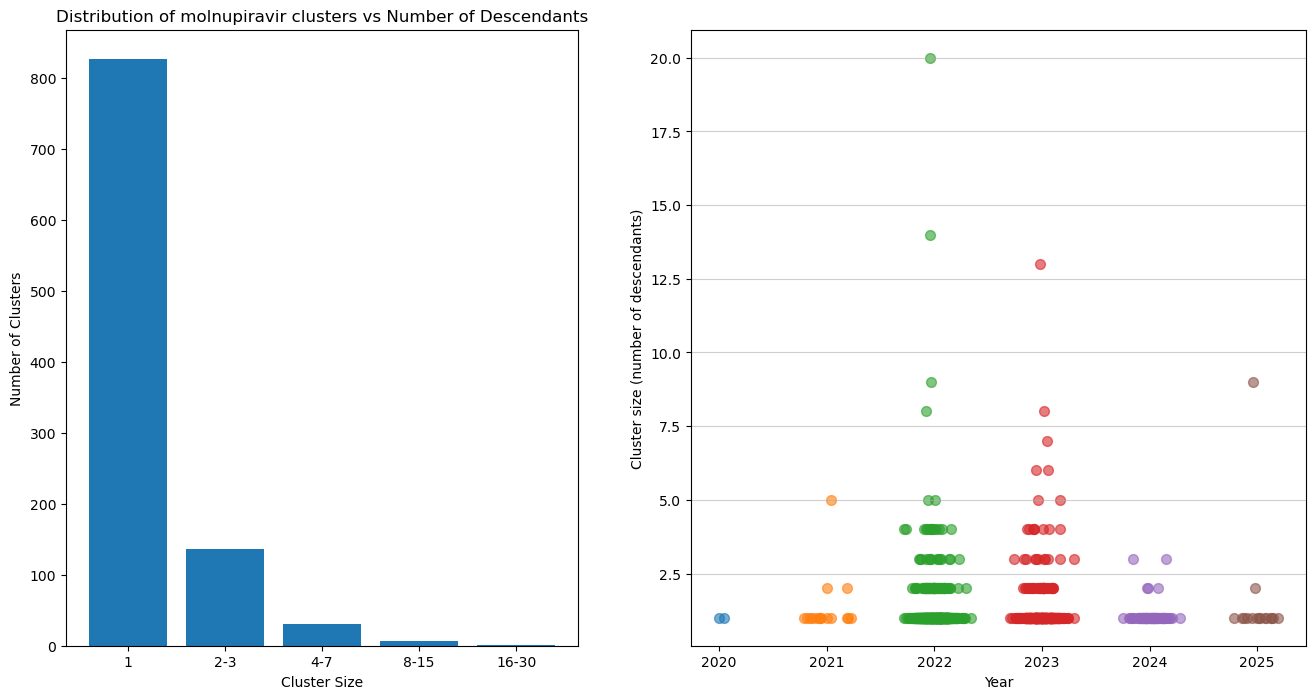

<Figure size 800x500 with 0 Axes>

In [34]:
# Figure 4A - Cluster size distribution of molnupiravir nodes by number of descendants
# Figure 4B - temporal analysis of molnupiravir cluster sizes across the years

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8),gridspec_kw={"width_ratios": [1, 1.2]})

# Panel A
bins = [1,2,4,8,16,32]
labels = ["1","2-3","4-7","8-15","16-30"]
df_mov = df[df["is_mov"]].copy()
df_mov["size_bin"] = pd.cut(df_mov["num_descendants"], bins=bins, right=False, labels=labels)

dist = df_mov.groupby("size_bin").size().reset_index(name="n_clusters")

ax1.bar(dist["size_bin"], dist["n_clusters"], color='#1f77b4')
ax1.set_xlabel("Cluster Size")
ax1.set_ylabel("Number of Clusters")
ax1.set_title("Distribution of molnupiravir clusters vs Number of Descendants")

# Expand data: create one row per count
df_plot = df_mov[["date","num_descendants"]].value_counts().reset_index()
df_plot.columns = ["year", "cluster_size", "n_clusters"]
df_plot.sort_values(by="year", inplace=True)
df_plot.head()

rows = []
for _, row in df_plot.iterrows():
    for i in range(int(row['n_clusters'])):
        rows.append({'year': row['year'], 'Cluster size': row['cluster_size']})
        
df_expanded = pd.DataFrame(rows) 

# Plot
plt.figure(figsize=(8, 5))
for year in df_expanded['year'].unique():
    data = df_expanded[df_expanded['year'] == year]
    x = data['year'] + np.random.normal(0, 0.1, len(data))
    y = data['Cluster size']
    ax2.scatter(x, y, alpha=0.6, s=50)
 

ax2.set_xlabel('Year')
ax2.set_ylabel('Cluster size (number of descendants)')
ax2.grid(axis='y', alpha=0.6)
plt.suptitle("Temporal distribution of molnupiravir cluster sizes", fontweight="bold", y=1.02)
plt.tight_layout()

plt.savefig("/Users/reem/molnupiravir_paper/Figures/figure4_cluster_sizes.pdf", format = "pdf", bbox_inches="tight")

plt.show()



In [ ]:
# Get total seqs per country
df = pd.read_csv("/Users/reem/merged_bte_final.tsv", sep="\t")


In [ ]:
# Get total sequences per country from the main BTE dataframe

total_seqs_per_country = df["country"].str.strip().value_counts().reset_index()
total_seqs_per_country.columns = ["country", "total_seqs"]
total_seqs_per_country = total_seqs_per_country.sort_values("total_seqs", ascending=False)
# Exclude countries with <= 1000 sequences for better visualization
total_seqs_per_country = total_seqs_per_country[total_seqs_per_country["total_seqs"] > 1000]
print(total_seqs_per_country)

In [43]:
total_seqs_per_country.to_csv("/Users/reem/total_seqs_per_country.tsv", sep="\t", index=False)

In [47]:
# Get total sequences per year from the main BTE dataframe
total_seqs_per_year = df["date"].value_counts().reset_index()
total_seqs_per_year.columns = ["year", "total_seqs"]
total_seqs_per_year = total_seqs_per_year.sort_values("year")
print(total_seqs_per_year)

   year  total_seqs
4  2020      392149
0  2021     3512086
1  2022     3359968
2  2023     1051324
3  2024      437747
5  2025      182426
6  2026         793


In [48]:
total_seqs_per_year.to_csv("/Users/reem/total_seqs_per_year.tsv", sep="\t", index=False)

In [38]:
year_counts = df_mov["date"].value_counts().reset_index()
year_counts.columns = ["year", "num_mov_clusters"]
year_counts.sort_values(by="year", inplace=True)
fig = px.bar(
    year_counts.sort_values(by="year"),
    x="year", y="num_mov_clusters",
    title="Number of MOV clusters per year",
    color_discrete_sequence=["indianred"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Number of MOV clusters")
fig.show()

In [39]:
fig.write_image("/Users/reem/new_figs/mov_clusters_per_year.svg")

In [ ]:
# Save value counts of years to a csv
year_counts.to_csv("/Users/reem/total_seqs_per_year.tsv",sep="\t", index=False)


In [30]:
year_counts = pd.read_csv("/Users/reem/total_seqs_per_year.tsv", sep="\t")

year_counts

,year,count
0,2019,50
1,2020,814241
2,2021,7341360
3,2022,6743816
4,2023,1549182
5,2024,580755
6,2025,213102
7,2026,1103


In [31]:
# Num Mov clusters per year
mov_counts_per_year = df["year"].value_counts().reset_index()
mov_counts_per_year.columns = ["year", "n_clusters"]
mov_counts_per_year.sort_values(by="year", inplace=True)
mov_counts_per_year

,year,n_clusters
5,2020,2
3,2021,16
0,2022,560
1,2023,329
2,2024,78
4,2025,16


In [33]:
plotly_df = pd.merge(year_counts, mov_counts_per_year, on="year", how="inner").fillna(0)
plotly_df

,year,count,n_clusters
0,2020,814241,2
1,2021,7341360,16
2,2022,6743816,560
3,2023,1549182,329
4,2024,580755,78
5,2025,213102,16


In [ ]:
# MOV_Clusters per year Normalized by total sequences per year
plotly_df["mov_normalized"] = (plotly_df["n_clusters"] / plotly_df["count"]) *1e6


fig = px.bar(
    plotly_df.sort_values(by="year"),
    x="year", y="mov_normalized",
    title="Number of MOV clusters normalized by total sequences per year",
    color_discrete_sequence=["indianred"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Number of molnupiravir clusters per million sequences")
fig.show()

In [35]:
fig.write_image("/Users/reem/new_figs/mov_clusters_per_year_normalized.svg")

In [ ]:
# Mov Percentage per year

year_totals = mov_counts_per_year.merge(year_counts, on="year")

year_totals["mov_percentage"] = (year_totals["n_clusters"] / year_totals["count"]) * 100

year_totals


fig = px.bar(
    year_totals.sort_values(by="year"),
    x="year", y="mov_percentage",
    title="Percentage of molnupiravir clusters per year",
    color_discrete_sequence=["purple"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Percentage of molnupiravir clusters (%)")
fig.show()


In [21]:
fig.write_image("/Users/reem/new_figs/percent_mov_clusters_per_year.svg")

In [46]:
# Functon to extract proportion of mov_seqs per country per year

def plot_mov_proportion(df, country):
    df_country = df[df["country"] == country]
    total_seqs = df_country["date"].value_counts().reset_index()
    mov_seqs = df_country[(df_country["LLR"]>3) & (df_country["sum_contexts"]>2)]["date"].value_counts().reset_index()
    #mov_seqs = df_country[df_country["sum_llrs"]>6]["date"].value_counts().reset_index()
    merged = total_seqs.merge(mov_seqs, on=total_seqs.columns[0], how="left").fillna(0)
    merged.columns = ["date", "total_seqs", "mov_seqs"]
    
    merged["proportion_mov"] = (merged["mov_seqs"] / merged["total_seqs"]) * 100
    merged = merged[merged["date"] != "0"].astype({"date": str})
    merged.drop(merged[(merged["date"] == "0") | (merged["date"] == "2020") | (merged["date"] == "2021") | (merged["date"] == "2026") | (merged["date"] == "1905")].index, inplace=True)
   
    fig = px.bar(merged.sort_values(by="date"),
        x="date", y="proportion_mov",
        title=f"Percentage of MOV sequences per year in {country}",
        color_discrete_sequence=["teal"]
    )
    fig.update_layout(xaxis_title="Year", yaxis_title="Percentage of MOV sequences (%)", font=dict(size=14))
    fig.update_yaxes(range=[0, 0.5])
    fig.show()
    fig.write_image(f"/Users/reem/new_figs/{country}_MOV_Proportion_per_Year.svg")
    return merged



plot_mov_proportion(df, country="Australia")      
#plot_mov_proportion(df, country="USA")

,date,total_seqs,mov_seqs,proportion_mov
0,2022,61506,187.0,0.304035
1,2023,27398,107.0,0.390539
3,2024,10305,20.0,0.194081
4,2025,7439,5.0,0.067213
